# Quantum Circuits

- In general terms, circuits are models of computation where wires represent information flow and gates represent operations on the information.

- Quantum circuits model quantum computation, where wires represent qubits and the gates represent unitary operations and measurements.

## Single Qubit Circuit

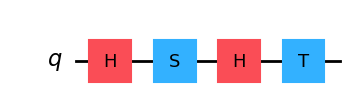

In [1]:
from qiskit import QuantumCircuit
from numpy import sqrt

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.s(0)
circuit.h(0)
circuit.t(0)

display(circuit.draw(output='mpl'))

In [2]:
from qiskit.quantum_info import Statevector

ket0 = Statevector.from_label('0')
display(ket0.draw('latex'))

<IPython.core.display.Latex object>

In [3]:
res = ket0.evolve(circuit)
display(res.draw('latex'))

<IPython.core.display.Latex object>

## Multiple Qubit Circuit

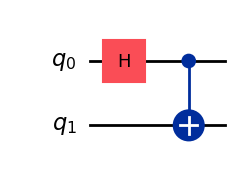

In [4]:
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)

display(circuit.draw(output='mpl'))

In [5]:
ket00 = ket0 ^ ket0
display(ket00.draw('latex'))

<IPython.core.display.Latex object>

In [6]:
phi_plus = ket00.evolve(circuit)
display(phi_plus.draw('latex'))

<IPython.core.display.Latex object>

In [10]:
outcome, state = phi_plus.measure()

print(outcome)
display(state.draw('latex'))

11


<IPython.core.display.Latex object>

## Inner Products and Orthogonality of Vectors

Given two arbitrary vectors of the same size,

$$
|\psi\rangle = 
\begin{pmatrix}
\alpha_1 \\
\vdots \\
\alpha_n
\end{pmatrix}
\quad \text{and} \quad
|\phi\rangle =
\begin{pmatrix}
\beta_1 \\
\vdots \\
\beta_n
\end{pmatrix}
$$

Their inner product is,

$$
\langle \psi | \phi \rangle =
\begin{pmatrix}
\overline{\alpha_1} & \cdots & \overline{\alpha_n}
\end{pmatrix}
\begin{pmatrix}
\beta_1 \\
\vdots \\
\beta_n
\end{pmatrix}
=\overline{\alpha_1}\beta_1 + \cdots + \overline{\alpha_n}\beta_n
$$

Alternatively in dirac notation the arbitrary vectors,

$$
|\psi\rangle = \sum_{a \in \Sigma} \alpha_a |a\rangle
\quad \text{and} \quad
|\phi\rangle = \sum_{b \in \Sigma} \beta_b |b\rangle
$$

have inner products as follows:

$$
\langle \psi | \phi \rangle =
\left( \sum_{a \in \Sigma} \overline{\alpha_a} \langle a| \right)
\left( \sum_{b \in \Sigma} \beta_b |b\rangle \right)
$$
$$
= \sum_{a \in \Sigma} \sum_{b \in \Sigma} \overline{\alpha_a} \beta_b \langle a | b \rangle
$$
$$
= \sum_{a \in \Sigma} \overline{\alpha_a} \beta_a
$$

In [34]:
phi = Statevector([1/2, sqrt(3)/2])
psi = Statevector([1/sqrt(2), -1/sqrt(2)])

display(phi.draw('latex'))
display(psi.draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [37]:
inner_product = psi.inner(phi)
print(inner_product)

(-0.25881904510252074+0j)


### Orthogonality of Vectors

- Orthogonal vectors are **perpendicular** to each others and make an angle of $90^0$ in between.
- The result of their inner product is zero

In [38]:
phi = Statevector([1/2, sqrt(3)/2])
psi = Statevector([sqrt(3)/2, -1/2])

display(phi.draw('latex'))
display(psi.draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [39]:
inner_product = psi.inner(phi)
print(inner_product)

0j


- Orthonormal vectors are orthogonal vectors of unit length.
- A set of orthonormal vectors that forms the basis of a given space is the othonormal basis of that space.

- The set $\{ |+\rangle |-\rangle \}$ is an orthonormal basis for the 2-dimensional space corresponding to a single qubit.

In [40]:
plus = Statevector.from_label('+')
display(plus.draw('latex'))

<IPython.core.display.Latex object>

In [41]:
minus = Statevector.from_label('-')
display(minus.draw('latex'))

<IPython.core.display.Latex object>

In [42]:
inner = plus.inner(minus)
print(inner)

0j


- The Bell basis $\{ | \phi^+ \rangle | \phi^-\rangle | \psi^+ \rangle | \psi^-\rangle \}$ is an orthonormal basis for the 4-dimensional space corresponding to two qubits.

In [50]:
def bell_state(state_type):
    qc = QuantumCircuit(2)
    
    # Create base Bell state (Phi+)
    qc.h(0)
    qc.cx(0, 1)
    
    # Modify to get other Bell states
    if state_type == "phi-":
        qc.z(0)
    elif state_type == "psi+":
        qc.x(1)
    elif state_type == "psi-":
        qc.x(1)
        qc.z(0)
    
    return Statevector.from_instruction(qc)

# Generate all Bell states
state_names = ["phi+", "phi-", "psi+", "psi-"]
states = {}

for s in state_names:
    sv = bell_state(s)
    print(f"{s}:")
    states[s] = sv
    display(sv.draw('latex'))

phi+:


<IPython.core.display.Latex object>

phi-:


<IPython.core.display.Latex object>

psi+:


<IPython.core.display.Latex object>

psi-:


<IPython.core.display.Latex object>

In [51]:
display(states["phi+"].draw('latex'))

<IPython.core.display.Latex object>

In [56]:
inner = states["phi+"].inner(states["phi-"])
print(inner)

0j


## Projections and Projective Measurements

### Projection Matrices


A square matrix $\Pi$ is called a **projection** (or **projector**) if it satisfies the following two properties:

**1. Idempotent Property**
$$
\Pi^2 = \Pi
$$

- Applying the projection twice has the same effect as applying it once.
- Once a vector is projected onto a subspace, projecting it again does not change it.

**2. Hermitian Property**
$$
\Pi^\dagger = \Pi
$$

- The matrix is equal to its own conjugate transpose.
- This ensures that measurement outcomes are physically valid (real-valued probabilities).

In quantum computing, a **projection matrix** typically refers to a matrix that satisfies **both**:

$$
\Pi^2 = \Pi \quad \text{and} \quad \Pi^\dagger = \Pi
$$

Such matrices are also called **orthogonal projectors**.

---


If $ | \psi \rangle $ is a unit vector, then this matrix is a projection:

$$ \Pi = | \psi \rangle \langle \psi | $$

Every projection matrix $ \Pi $ takes the form: 
$$
\Pi = \sum_{k=1}^{m} |\psi_k\rangle \langle \psi_k|
$$
for some orthonormal set $ \{|\psi_1\rangle, \ldots, |\psi_m\rangle\} $.  

(This includes the case $ \Pi = 0 $.)

In [11]:
from qiskit.quantum_info import DensityMatrix

psi = Statevector.from_label('0')
display(psi.draw('latex'))

<IPython.core.display.Latex object>

In [12]:
rho = DensityMatrix(psi)
display(rho.draw('latex'))

<IPython.core.display.Latex object>

#### Apply projection on an arbitrary statevector

In [13]:
psi = Statevector([sqrt(3)/2, -1/2])
display(psi.draw('latex'))

<IPython.core.display.Latex object>

- Keeps only the component along $| 0 \rangle$

In [15]:
phi = psi.evolve(rho)
display(phi.draw('latex'))

<IPython.core.display.Latex object>

### Projective Measurements

A collection of projections $\{\Pi_1, \ldots, \Pi_m\}$ that satisfies

$$
\Pi_1 + \cdots + \Pi_m = \mathbb{1}
$$

describes a *projective measurement*.

When such a measurement is performed on a system in the state $|\psi\rangle$, two things happen:

1. The outcome $k \in \{1, \ldots, m\}$ of the measurement is chosen randomly:

$$
\Pr(\text{outcome is } k) = \|\Pi_k |\psi\rangle\|^2 = \langle \psi | \Pi_k | \psi \rangle
$$

2. The state of the system becomes

$$
\frac{\Pi_k |\psi\rangle}{\|\Pi_k |\psi\rangle\|}
$$

#### Projective Measurements in the $| + \rangle$, $| - \rangle$ basis

In [34]:
# Given an arbitrary statevector phi

phi = Statevector([1 / sqrt(3), sqrt(2) / sqrt(3)])
print('phi:')
display(phi.draw('latex'))

phi:


<IPython.core.display.Latex object>

In [35]:
plus = Statevector.from_label('+')
minus = Statevector.from_label('-')

In [37]:
pi0 = DensityMatrix(plus)
pi1 = DensityMatrix(minus)

print("Pi-0")
display(pi0.draw('latex'))

print("Pi-1")
display(pi1.draw('latex'))

Pi-0


<IPython.core.display.Latex object>

Pi-1


<IPython.core.display.Latex object>

In [38]:
proj0 = phi.evolve(pi0)

print("Proj-0")
display(proj0.draw('latex'))

Proj-0


<IPython.core.display.Latex object>

In [39]:
proj1 = phi.evolve(pi1)

print("Proj-1")
display(proj1.draw('latex'))

Proj-1


<IPython.core.display.Latex object>

In [45]:
# Probability of measuring ancilla as 0

probability = proj0.inner(proj0)
print(f"Pr(Outcome is 0): {probability}")

new_state = Statevector.from_label('0') ^ (proj0 / sqrt(probability))
print("State if 0 measured:")
display(new_state.draw('latex'))

Pr(Outcome is 0): (0.9714045207910313+0j)
State if 0 measured:


<IPython.core.display.Latex object>

In [46]:
# Probability of measuring ancilla as 1

probability = proj1.inner(proj1)
print(f"Pr(Outcome is 1): {probability}")

new_state = Statevector.from_label('1') ^ (proj1 / sqrt(probability))
print("State if 1 measured:")
display(new_state.draw('latex'))

Pr(Outcome is 1): (0.028595479208968298+0j)
State if 1 measured:


<IPython.core.display.Latex object>